In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here are several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/gym-members-exercise-dataset/gym_members_exercise_tracking.csv
/kaggle/input/fitness-tracker-dataset/gym_members_exercise_tracking_synthetic_data.csv
/kaggle/input/life-style-data/Final_data.csv
/kaggle/input/life-style-data/meal_metadata.csv
/kaggle/input/running-calorie-burn-dataset/calories_burned_data.csv


Importing Libraries

In [72]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import plotly as px
import random

In [3]:
df1 = pd.read_csv('/kaggle/input/life-style-data/Final_data.csv')
df1.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12  Workout_Frequency (days/week)   

# EDA 

Removal of unwanted columns

In [5]:
df1['Calories_intake']=df1['Calories']

In [6]:
df1=df1.drop(columns=['Burns_Calories_Bin','Burns Calories (per 30 min)_bc','Burns Calories (per 30 min)','Calories','meal_name',
          'meal_type','prep_time_min','cook_time_min','rating','Equipment Needed','Type of Muscle','BMI_calc',
          'cal_from_macro','protein_per_kg','pct_maxHR','expected_burn'],axis=1, errors='ignore')

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            20000 non-null  float64
 1   Gender                         20000 non-null  object 
 2   Weight (kg)                    20000 non-null  float64
 3   Height (m)                     20000 non-null  float64
 4   Max_BPM                        20000 non-null  float64
 5   Avg_BPM                        20000 non-null  float64
 6   Resting_BPM                    20000 non-null  float64
 7   Session_Duration (hours)       20000 non-null  float64
 8   Calories_Burned                20000 non-null  float64
 9   Workout_Type                   20000 non-null  object 
 10  Fat_Percentage                 20000 non-null  float64
 11  Water_Intake (liters)          20000 non-null  float64
 12  Workout_Frequency (days/week)  20000 non-null 

In [8]:
numerical_cols=[]
for col in df1.columns:
    if df1[col].dtype ==float :
        numerical_cols.append(col)

In [9]:
categorical_cols = list(set(df1.columns) - set(numerical_cols))

In [10]:
df1_numerical=df1[numerical_cols]

In [11]:
df1_numerical

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),...,cholesterol_mg,serving_size_g,Sets,Reps,cal_from_macros,pct_carbs,pct_HRR,cal_balance,lean_mass_kg,Calories_intake
0,34.91,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,1.50,...,285.05,120.47,4.99,20.91,2139.59,0.500432,0.741237,725.10,47.777394,1806.0
1,23.37,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,1.90,...,300.61,109.15,4.01,16.15,1711.65,0.500850,0.551247,-232.91,40.809803,1577.0
2,33.20,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,1.88,...,215.42,399.43,5.00,21.90,1965.92,0.500610,0.574534,805.74,44.635580,1608.0
3,38.69,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,2.50,...,9.70,314.31,4.01,16.92,1627.28,0.499533,0.744155,1206.21,63.007432,2657.0
4,45.09,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,2.91,...,116.89,99.22,4.99,15.01,2659.23,0.500581,0.668405,303.60,43.347504,1470.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,46.77,98.31,1.90,199.20,148.18,63.72,0.77,761.61,27.505498,2.99,...,243.54,190.52,4.99,17.14,1882.80,0.500000,0.623413,1865.39,71.269345,2627.0
19996,40.38,88.12,1.87,196.18,134.18,54.04,1.97,2303.13,26.180562,3.52,...,188.76,468.81,5.01,23.08,1205.47,0.496968,0.563810,173.87,65.049689,2477.0
19997,50.31,46.20,1.67,163.34,157.92,61.65,1.36,1468.80,23.331802,2.81,...,80.47,244.51,4.00,18.91,1947.79,0.500280,0.946701,-43.80,35.420708,1425.0
19998,52.36,44.30,1.62,179.27,121.23,60.88,1.41,929.75,18.985868,1.59,...,245.91,402.26,3.99,24.97,1921.51,0.499940,0.509756,346.25,35.889260,1276.0


In [12]:
df1_categorical=df1[categorical_cols]

In [13]:
df1_categorical

,Body Part,cooking_method,Benefit,Name of Exercise,Target Muscle Group,Workout_Type,Workout,Difficulty Level,diet_type,Gender
0,Legs,Grilled,Improves shoulder health and posture,Decline Push-ups,"Shoulders, Triceps",Strength,Dumbbell flyes,Advanced,Vegan,Male
1,Chest,Fried,Strengthens lower abs,Bear Crawls,"Back, Core, Shoulders",HIIT,Lateral raises,Intermediate,Vegetarian,Female
2,Arms,Boiled,Builds chest strength,Dips,"Quadriceps, Glutes",Cardio,Standing calf raises,Intermediate,Paleo,Female
3,Shoulders,Fried,Improves coordination and cardiovascular health,Mountain Climbers,"Biceps, Forearms",HIIT,Incline dumbbell flyes,Advanced,Paleo,Female
4,Abs,Baked,Targets obliques and improves core rotation,Bicep Curls,"Chest, Triceps",Strength,Military press,Advanced,Vegan,Male
...,...,...,...,...,...,...,...,...,...,...
19995,Arms,Boiled,Improves cardiovascular fitness,Frog Jumps,"Quadriceps, Hamstrings, Glutes",Strength,Triceps pushdowns,Advanced,Low-Carb,Female
19996,Arms,Boiled,Strengthens back and legs,Pull-ups,"Core, Shoulders, Hips",Strength,Seated calf raises,Intermediate,Vegetarian,Female
19997,Forearms,Grilled,Builds shoulder width,Dips,"Upper Back, Rear Deltoids",Strength,Russian twists,Beginner,Keto,Male
19998,Shoulders,Roasted,Builds calf muscles,Plyo Squats,"Rear Deltoids, Upper Back",Yoga,Leg curls,Intermediate,Paleo,Male


# EDA on numerical data

In [14]:
import plotly as px
import scipy as stats
import matplotlib.pyplot as plt
import seaborn as sns

Univariate analysis of important columns

In [15]:
df1_numerical.drop(columns=['cal_balance'],axis=1, errors='ignore')

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),...,sodium_mg,cholesterol_mg,serving_size_g,Sets,Reps,cal_from_macros,pct_carbs,pct_HRR,lean_mass_kg,Calories_intake
0,34.91,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,1.50,...,1729.94,285.05,120.47,4.99,20.91,2139.59,0.500432,0.741237,47.777394,1806.0
1,23.37,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,1.90,...,693.08,300.61,109.15,4.01,16.15,1711.65,0.500850,0.551247,40.809803,1577.0
2,33.20,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,1.88,...,2142.48,215.42,399.43,5.00,21.90,1965.92,0.500610,0.574534,44.635580,1608.0
3,38.69,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,2.50,...,123.20,9.70,314.31,4.01,16.92,1627.28,0.499533,0.744155,63.007432,2657.0
4,45.09,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,2.91,...,1935.11,116.89,99.22,4.99,15.01,2659.23,0.500581,0.668405,43.347504,1470.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,46.77,98.31,1.90,199.20,148.18,63.72,0.77,761.61,27.505498,2.99,...,1241.30,243.54,190.52,4.99,17.14,1882.80,0.500000,0.623413,71.269345,2627.0
19996,40.38,88.12,1.87,196.18,134.18,54.04,1.97,2303.13,26.180562,3.52,...,1853.10,188.76,468.81,5.01,23.08,1205.47,0.496968,0.563810,65.049689,2477.0
19997,50.31,46.20,1.67,163.34,157.92,61.65,1.36,1468.80,23.331802,2.81,...,1808.43,80.47,244.51,4.00,18.91,1947.79,0.500280,0.946701,35.420708,1425.0
19998,52.36,44.30,1.62,179.27,121.23,60.88,1.41,929.75,18.985868,1.59,...,2125.57,245.91,402.26,3.99,24.97,1921.51,0.499940,0.509756,35.889260,1276.0


In [16]:
# Correlation of numerical features.
df1_numerical.corr()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),...,cholesterol_mg,serving_size_g,Sets,Reps,cal_from_macros,pct_carbs,pct_HRR,cal_balance,lean_mass_kg,Calories_intake
Age,1.000000,-0.044077,-0.037096,-0.028763,0.039280,0.013387,-0.025410,-0.021396,-0.025056,0.037569,...,0.012642,0.008652,0.020391,-0.028396,0.052045,-0.005022,0.044258,-0.015984,-0.050547,-0.041096
Weight (kg),-0.044077,1.000000,0.353763,0.066898,0.016761,-0.033578,-0.002275,-0.001994,0.778875,0.397971,...,0.019324,0.037870,0.008588,-0.026516,-0.003569,-0.001333,-0.016656,0.736698,0.981897,0.978273
Height (m),-0.037096,0.353763,1.000000,-0.014397,-0.012135,0.009897,0.006783,0.009211,-0.156586,0.398041,...,0.028149,0.037035,-0.017659,0.003823,0.008076,0.012513,-0.012385,0.254356,0.477397,0.346939
Max_BPM,-0.028763,0.066898,-0.014397,1.000000,-0.028047,0.035522,0.009767,0.003136,0.071926,0.041635,...,-0.017007,-0.035836,-0.030289,-0.041817,-0.010566,-0.004370,-0.511858,0.043785,0.060146,0.061159
Avg_BPM,0.039280,0.016761,-0.012135,-0.028047,1.000000,0.063042,0.018553,0.007984,0.009022,0.006192,...,-0.013604,0.017602,-0.046259,-0.031312,0.033147,-0.005017,0.856732,0.005324,0.012083,0.014483
Resting_BPM,0.013387,-0.033578,0.009897,0.035522,0.063042,1.000000,-0.017554,-0.001633,-0.042021,0.011676,...,-0.030547,-0.004578,0.002984,0.001295,0.042500,-0.016604,-0.088468,-0.024921,-0.030811,-0.034669
Session_Duration (hours),-0.025410,-0.002275,0.006783,0.009767,0.018553,-0.017554,1.000000,0.814368,-0.034861,0.287751,...,0.092605,0.045158,0.011456,0.033300,0.010536,0.007848,0.017835,-0.528619,0.025165,0.051474
Calories_Burned,-0.021396,-0.001994,0.009211,0.003136,0.007984,-0.001633,0.814368,1.000000,-0.033812,0.262731,...,0.072296,0.029458,0.024164,0.043237,0.011817,0.009419,0.010506,-0.660560,0.023134,0.047981
Fat_Percentage,-0.025056,0.778875,-0.156586,0.071926,0.009022,-0.042021,-0.034861,-0.033812,1.000000,0.185207,...,0.004705,0.017901,0.006836,-0.033799,-0.012551,-0.003533,-0.020686,0.594499,0.659078,0.759601
Water_Intake (liters),0.037569,0.397971,0.398041,0.041635,0.006192,0.011676,0.287751,0.262731,0.185207,1.000000,...,0.023674,0.005520,0.005125,-0.032642,0.045292,0.006100,-0.019804,0.126435,0.435249,0.411713


In [17]:
df1_categorical

,Body Part,cooking_method,Benefit,Name of Exercise,Target Muscle Group,Workout_Type,Workout,Difficulty Level,diet_type,Gender
0,Legs,Grilled,Improves shoulder health and posture,Decline Push-ups,"Shoulders, Triceps",Strength,Dumbbell flyes,Advanced,Vegan,Male
1,Chest,Fried,Strengthens lower abs,Bear Crawls,"Back, Core, Shoulders",HIIT,Lateral raises,Intermediate,Vegetarian,Female
2,Arms,Boiled,Builds chest strength,Dips,"Quadriceps, Glutes",Cardio,Standing calf raises,Intermediate,Paleo,Female
3,Shoulders,Fried,Improves coordination and cardiovascular health,Mountain Climbers,"Biceps, Forearms",HIIT,Incline dumbbell flyes,Advanced,Paleo,Female
4,Abs,Baked,Targets obliques and improves core rotation,Bicep Curls,"Chest, Triceps",Strength,Military press,Advanced,Vegan,Male
...,...,...,...,...,...,...,...,...,...,...
19995,Arms,Boiled,Improves cardiovascular fitness,Frog Jumps,"Quadriceps, Hamstrings, Glutes",Strength,Triceps pushdowns,Advanced,Low-Carb,Female
19996,Arms,Boiled,Strengthens back and legs,Pull-ups,"Core, Shoulders, Hips",Strength,Seated calf raises,Intermediate,Vegetarian,Female
19997,Forearms,Grilled,Builds shoulder width,Dips,"Upper Back, Rear Deltoids",Strength,Russian twists,Beginner,Keto,Male
19998,Shoulders,Roasted,Builds calf muscles,Plyo Squats,"Rear Deltoids, Upper Back",Yoga,Leg curls,Intermediate,Paleo,Male


In [18]:
# Columns in df1 dataset
df1.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI',
       'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins',
       'Fats', 'diet_type', 'sugar_g', 'sodium_mg', 'cholesterol_mg',
       'serving_size_g', 'cooking_method', 'Name of Exercise', 'Sets', 'Reps',
       'Benefit', 'Target Muscle Group', 'Difficulty Level', 'Body Part',
       'Workout', 'cal_from_macros', 'pct_carbs', 'pct_HRR', 'cal_balance',
       'lean_mass_kg', 'Calories_intake'],
      dtype='object')

In [19]:
for col in df1_categorical.columns:
    print(f"Column : {col}")
    print(df1[col].unique())

Column : Body Part
['Legs' 'Chest' 'Arms' 'Shoulders' 'Abs' 'Back' 'Forearms']
Column : cooking_method
['Grilled' 'Fried' 'Boiled' 'Baked' 'Steamed' 'Raw' 'Roasted']
Column : Benefit
['Improves shoulder health and posture' 'Strengthens lower abs'
 'Builds chest strength' 'Improves coordination and cardiovascular health'
 'Targets obliques and improves core rotation' 'Builds explosive power'
 'Strengthens back and improves posture'
 'Improves core stability and upper body strength' 'Full body workout'
 'Strengthens lower body' 'Isolates triceps'
 'Builds unilateral leg strength and balance' 'Improves core stability'
 'Improves core stability and balance' 'Improves balance and leg strength'
 'Improves posture and strengthens upper back'
 'Isolates and strengthens triceps' 'Targets upper chest'
 'Strengthens back and legs' 'Improves shoulder mobility and posture'
 'Builds upper body strength' 'Builds shoulder width'
 'Advanced core exercise' 'Targets biceps and forearms'
 'Improves lower 

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


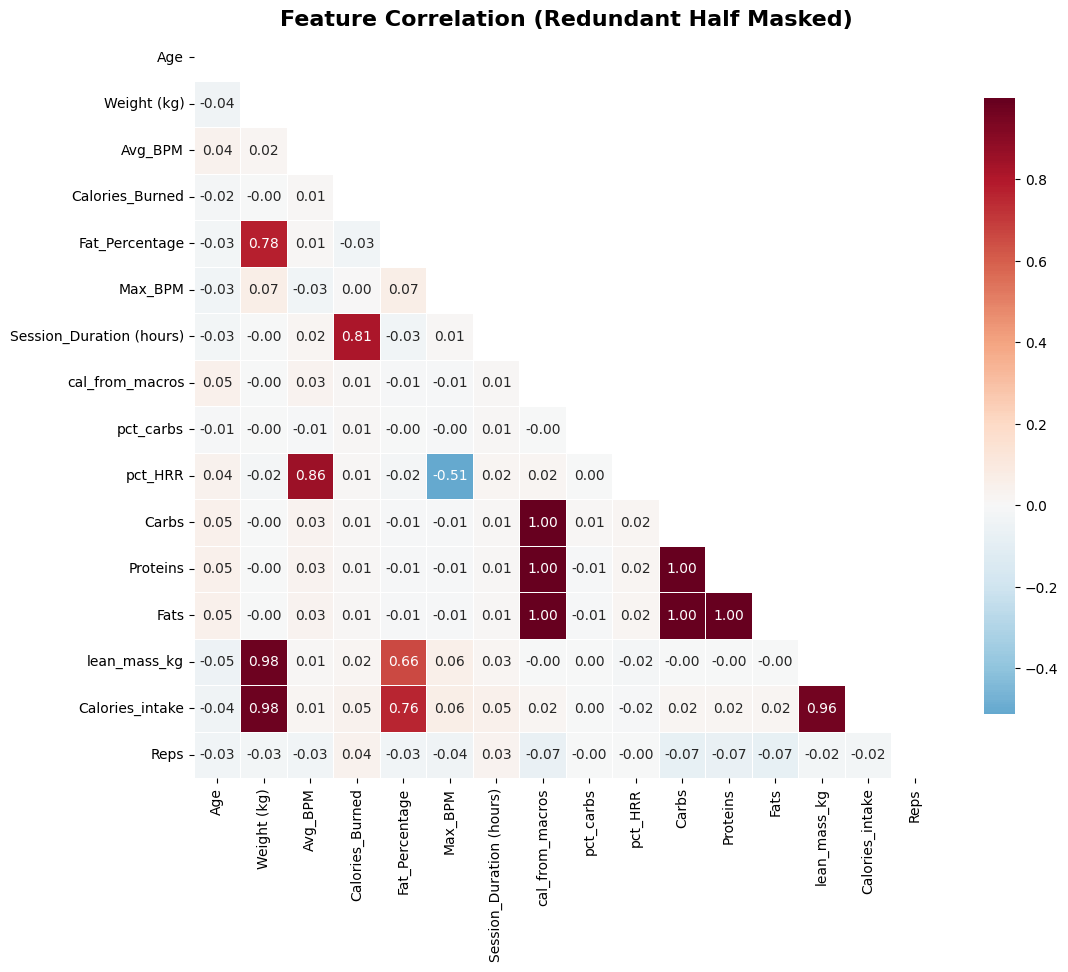

In [20]:
# Heatmap of important numerical features.

plt.figure(figsize=(12, 10))
corr = df1[['Age', 'Weight (kg)', 'Avg_BPM', 'Calories_Burned', 'Fat_Percentage',
            'Max_BPM', 'Session_Duration (hours)','cal_from_macros', 'pct_carbs',
            'pct_HRR','Carbs', 'Proteins','Fats','lean_mass_kg', 'Calories_intake', 'Reps']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation (Redundant Half Masked)', fontsize=16, fontweight='bold')
plt.show()

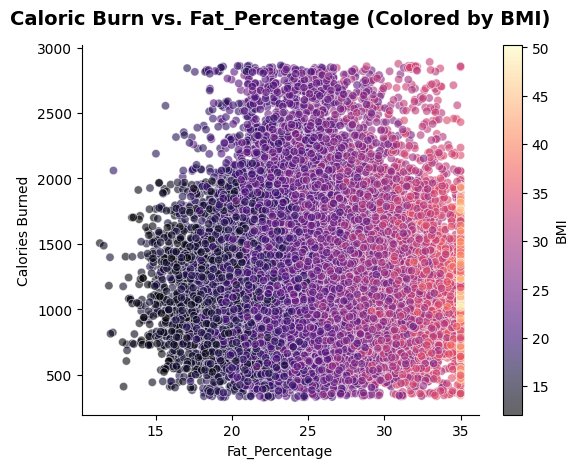

<Figure size 1200x1000 with 0 Axes>

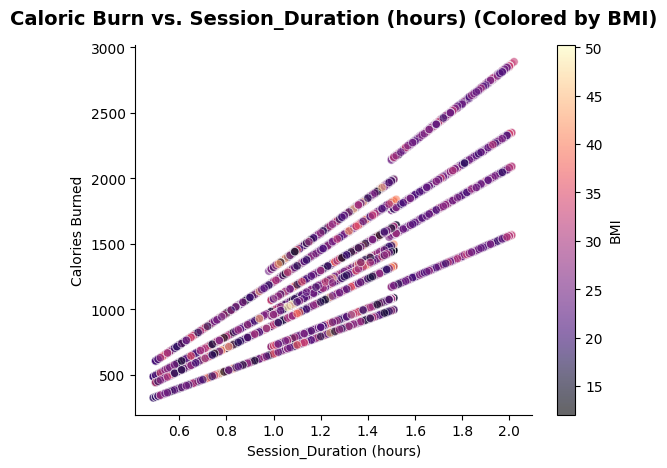

<Figure size 1200x1000 with 0 Axes>

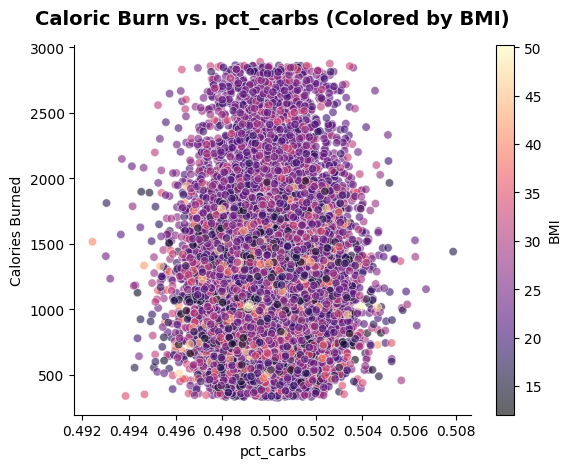

<Figure size 1200x1000 with 0 Axes>

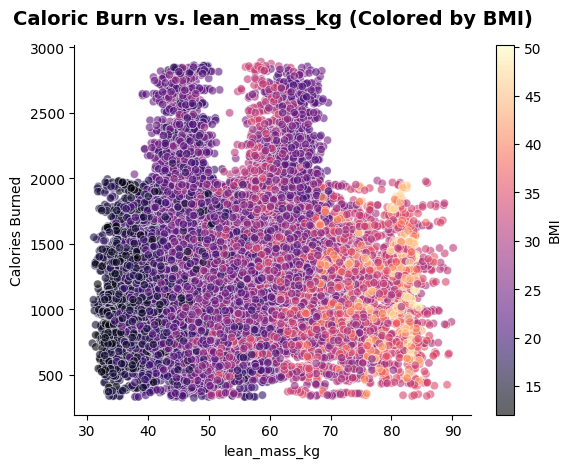

<Figure size 1200x1000 with 0 Axes>

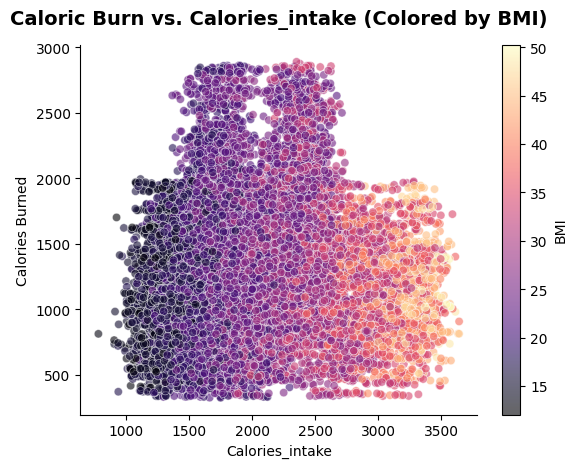

<Figure size 1200x1000 with 0 Axes>

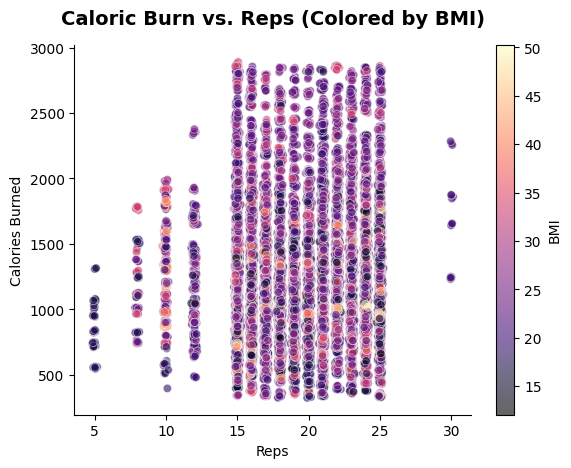

<Figure size 1200x1000 with 0 Axes>

In [21]:
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

num_feature=['Fat_Percentage', 'Session_Duration (hours)', 'pct_carbs',
            'lean_mass_kg', 'Calories_intake', 'Reps']
for col in num_feature:
    scatter = plt.scatter(df1[col], 
                          df1['Calories_Burned'], 
                          c=df1['BMI'], 
                          cmap='magma', # Perceptually uniform & elegant
                          alpha=0.6, 
                          edgecolors='w', 
                          linewidth=0.5)
    
    plt.title(f'Caloric Burn vs. {col} (Colored by BMI)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(col)
    plt.ylabel('Calories Burned')
    cbar = plt.colorbar(scatter)
    cbar.set_label('BMI')
    plt.figure(figsize=(12,10))
    plt.show()

Important Inferences
1. High-calorie burn in repetition of 15 to 25 times.
2. High repetition is done by person with lower BMI.
3. Daily calorie intake is around 1500 to 2500 calories by people with high calory burn.
4. High BMI people take high calorie diet.
5. Lean mass with 40 to 65 has high calorie burn

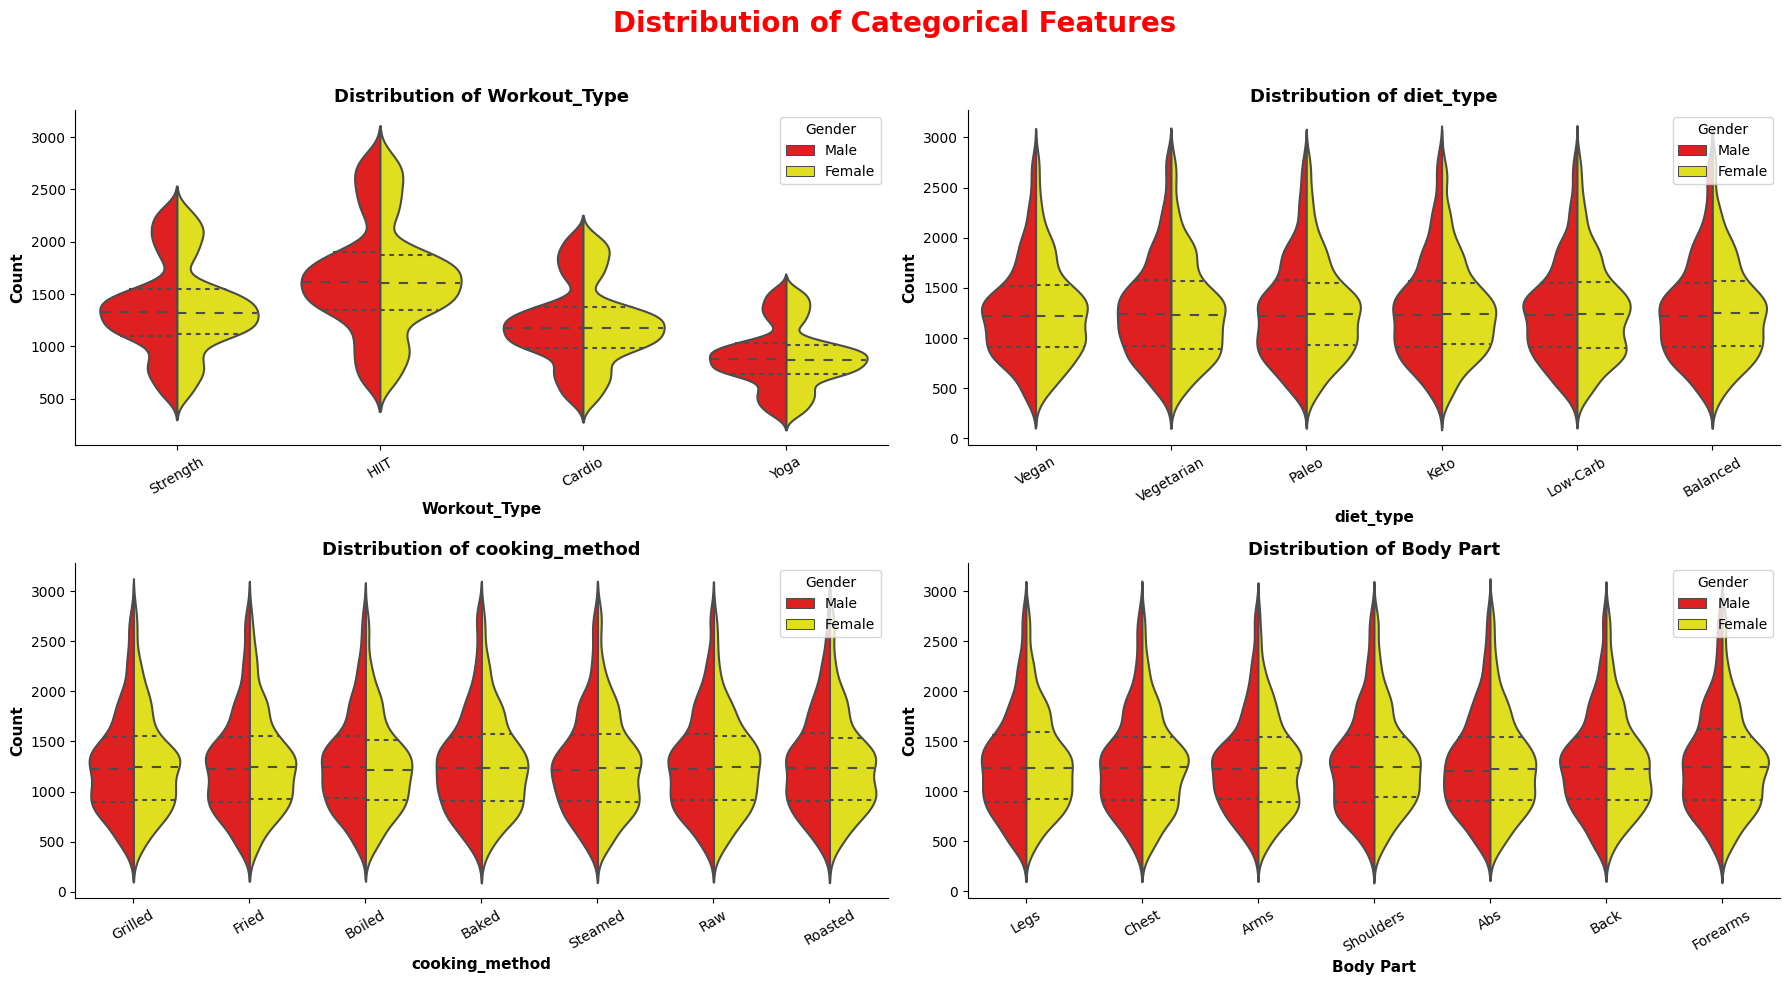

In [22]:
from matplotlib import axes

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

plt.style.use('seaborn-v0_8-muted')
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

cat_feature=['Workout_Type','diet_type','cooking_method','Body Part']
for i, feature in enumerate(cat_feature):
    sns.violinplot(data=df1, x=feature, y='Calories_Burned', 
                   hue='Gender', split=True, inner="quart",ax=axes[i],
                   palette={"Male": "RED", "Female": "Yellow"} # Nord Colors
                 )
    

    # sns.countplot(data=df, x=feature, ax=axes[i], palette='viridis')
    axes[i].set_title(f"Distribution of {feature}", fontweight="bold", fontsize=13)
    axes[i].set_xlabel(feature, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Count", fontsize=11, fontweight="bold")
    axes[i].tick_params(axis='x', rotation=30)
    
plt.suptitle("Distribution of Categorical Features", fontsize=20, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [23]:
numerical_cols

['Age',
 'Weight (kg)',
 'Height (m)',
 'Max_BPM',
 'Avg_BPM',
 'Resting_BPM',
 'Session_Duration (hours)',
 'Calories_Burned',
 'Fat_Percentage',
 'Water_Intake (liters)',
 'Workout_Frequency (days/week)',
 'Experience_Level',
 'BMI',
 'Daily meals frequency',
 'Physical exercise',
 'Carbs',
 'Proteins',
 'Fats',
 'sugar_g',
 'sodium_mg',
 'cholesterol_mg',
 'serving_size_g',
 'Sets',
 'Reps',
 'cal_from_macros',
 'pct_carbs',
 'pct_HRR',
 'cal_balance',
 'lean_mass_kg',
 'Calories_intake']

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
import xgboost as xgb
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, Ridge
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor, Pool
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PowerTransformer, OneHotEncoder


In [65]:
X_train,X_test,y_train,y_test=train_test_split(df1_numerical.drop(columns=['Calories_Burned']),df1_numerical['Calories_Burned'],random_state=42,test_size=0.2)

Numerical Columns Transformation

In [85]:
from sklearn.model_selection import cross_val_score

mms = MinMaxScaler()
X_train = mms.fit_transform(X_train)
X_test = mms.transform(X_test)

In [86]:
lr = Ridge()

lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.9997779958427045

In [87]:
from sklearn.linear_model import RidgeCV

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train, y_train)

print("Best alpha:", ridge_cv.alpha_)

y_pred = ridge_cv.predict(X_test)

from sklearn.metrics import r2_score

print("Test R²:", r2_score(y_test, y_pred))

Best alpha: 0.001
Test R²: 0.9999999997503414


In [89]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=kf,
    scoring='r2'
)

print("R² scores for each fold:", scores)
print("Mean R²:", np.mean(scores))
print("Standard Deviation:", np.std(scores))

R² scores for each fold: [0.99966071 0.99966804 0.99967232 0.99967721 0.99968083]
Mean R²: 0.9996718215195634
Standard Deviation: 7.046991809351006e-06


In [97]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

0.007890539372218027

In [81]:
class RigRegression:

    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.coef_ =None
        self.intercept = None

    def fit(self, X_train, y_train):

        # Add bias column
        X_train = np.insert(X_train, 0, 1, axis=1)

        # Identity matrix of size (number of features)
        I = np.eye(X_train.shape[1])
        I[0,0] = 0

        betas = np.linalg.inv(
            X_train.T @ X_train + self.alpha * I
        ) @ X_train.T @ y_train

        self.intercept = betas[0]
        self.coef_ = betas[1:]

In [84]:
rd = RigRegression()
rd.fit(X_train,y_train)
y_pred_rd = lr.predict(X_test)

r2_score(y_test,y_pred_rd)

0.9997779958427045

In [99]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rd))
rmse

7.440702281452309

In [78]:
print(lr.coef_)

[ 5.84428415e-02  8.17483080e+01  2.40180133e+00  1.40212069e+00
 -2.66991229e+00  4.80216551e-01  2.95821013e+01  4.29297635e+00
  5.80933427e-01  7.18323896e+00  5.37893803e+00  7.30223678e+00
  2.68666025e-01  4.19219463e+00 -3.83515581e-01 -2.14732852e-01
  1.55923000e-01  1.01101293e-01  2.71274157e-01  5.69596480e-01
 -4.98579664e-02  2.21339682e-01  5.64371226e-01 -1.88278183e-01
  2.72857816e-01  4.48961972e+00 -4.25448524e+03  1.64714040e+01
  2.67036614e+03]


In [74]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt = DecisionTreeRegressor(criterion='squared_error')
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)

r2_score(y_pred,y_test)

0.9895482470365782

In [75]:
rf= RandomForestRegressor()

rf = RandomForestRegressor()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

r2_score(y_pred,y_test)

0.9968491171863576

In [78]:
Xtrain,Xtest,ytrain,ytest=train_test_split(df1.drop(columns=['Calories_Burned']),df1['Calories_Burned'],random_state=42,test_size=0.2)

In [82]:
# Main model as catboost

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

# Model Fitting 

cat_model.fit(
    Xtrain,
    ytrain,
    cat_features=categorical_cols,
    eval_set=(Xtest, ytest)
)

# Model Prediction

y_pred_cat = cat_model.predict(Xtest)

rmse_cat = mean_squared_error(ytest, y_pred_cat, squared=False)
r2_cat = r2_score(ytest, y_pred_cat)

print("CatBoost RMSE:", rmse_cat)
print("CatBoost R²:", r2_cat)


0:	learn: 479.2862803	test: 475.9423602	best: 475.9423602 (0)	total: 47.1ms	remaining: 23.5s
100:	learn: 16.0504754	test: 13.5735741	best: 13.5735741 (100)	total: 3.84s	remaining: 15.2s
200:	learn: 10.8744725	test: 9.6989244	best: 9.6989244 (200)	total: 7.73s	remaining: 11.5s
300:	learn: 8.2007412	test: 7.4909884	best: 7.4909884 (300)	total: 11.7s	remaining: 7.72s
400:	learn: 6.7469510	test: 6.3277398	best: 6.3277398 (400)	total: 15.8s	remaining: 3.9s
499:	learn: 5.7478736	test: 5.6185458	best: 5.6185458 (499)	total: 19.9s	remaining: 0us

bestTest = 5.618545794
bestIteration = 499

CatBoost RMSE: 5.618545686226043
CatBoost R²: 0.999873415338449
